# Taller 06: Modelos de Clasificación

0. Importación de librerías
1. Carga de datos y análisis exploratorio
2. Preprocesamiento e ingeniería de características
3. División del dataset (train/test) y escalado
4. Entrenamiento de los tres modelos
5. Evaluación, comparación y selección del mejor modelo
6. Conclusiones

In [1]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Partición de datos, validación cruzada y búsqueda de hiperparámetros
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Escalado de variables numéricas
from sklearn.preprocessing import StandardScaler

# Los tres clasificadores que vamos a comparar
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Configuración general
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42   # semilla fija para que los resultados sean replicables

## 1. Carga de Datos y Análisis Exploratorio Inicial

| Variable | Descripción |
|---|---|
| `ID` | Identificador del envío |
| `Warehouse_block` | Bloque del almacén |
| `Mode_of_Shipment` | Medio de transporte |
| `Customer_care_calls` | Llamadas al servicio al cliente para consultar por el envío |
| `Customer_rating` | Calificación del cliente |
| `Cost_of_the_Product` | Costo del producto |
| `Prior_purchases` | Número de compras previas del cliente |
| `Product_importance` | Importancia del producto |
| `Gender` | Género del cliente |
| `Discount_offered` | Descuento ofrecido |
| `Weight_in_gms` | Peso del producto |
| `Reached.on.Time_Y.N` | **Variable objetivo.** `1` = el envío **no** llegó a tiempo (retraso), `0` = llegó a tiempo |

> **Aunque la columna se llama `Reached.on.Time`, `1` indica que el producto **NO** llegó a tiempo.

In [ ]:
# Paso 1: Carga del dataset descargado
TARGET = "Reached.on.Time_Y.N"

df = pd.read_csv("Train.csv")
print("Dimensiones del dataset (filas, columnas):", df.shape)
df.head()

Dimensiones del dataset (filas, columnas): (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
# Tipos de datos, valores nulos y duplicados
df.info()
print("\nValores nulos por columna:")
print(df.isnull().sum().to_string())
print("\nFilas duplicadas:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB

Valores nulos por columna:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_

In [4]:
# Estadísticos descriptivos de las variables numéricas (observar escalas y rangos)
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ID,10999.0,5500.00,3175.28,1.0,2750.5,5500.0,8249.5,10999.0
Customer_care_calls,10999.0,4.05,1.14,2.0,3.0,4.0,5.0,7.0
Customer_rating,10999.0,2.99,1.41,1.0,2.0,3.0,4.0,5.0
Cost_of_the_Product,10999.0,210.20,48.06,96.0,169.0,214.0,251.0,310.0
Prior_purchases,10999.0,3.57,1.52,2.0,3.0,3.0,4.0,10.0
Discount_offered,10999.0,13.37,16.21,1.0,4.0,7.0,10.0,65.0
Weight_in_gms,10999.0,3634.02,1635.38,1001.0,1839.5,4149.0,5050.0,7846.0
Reached.on.Time_Y.N,10999.0,0.60,0.49,0.0,0.0,1.0,1.0,1.0


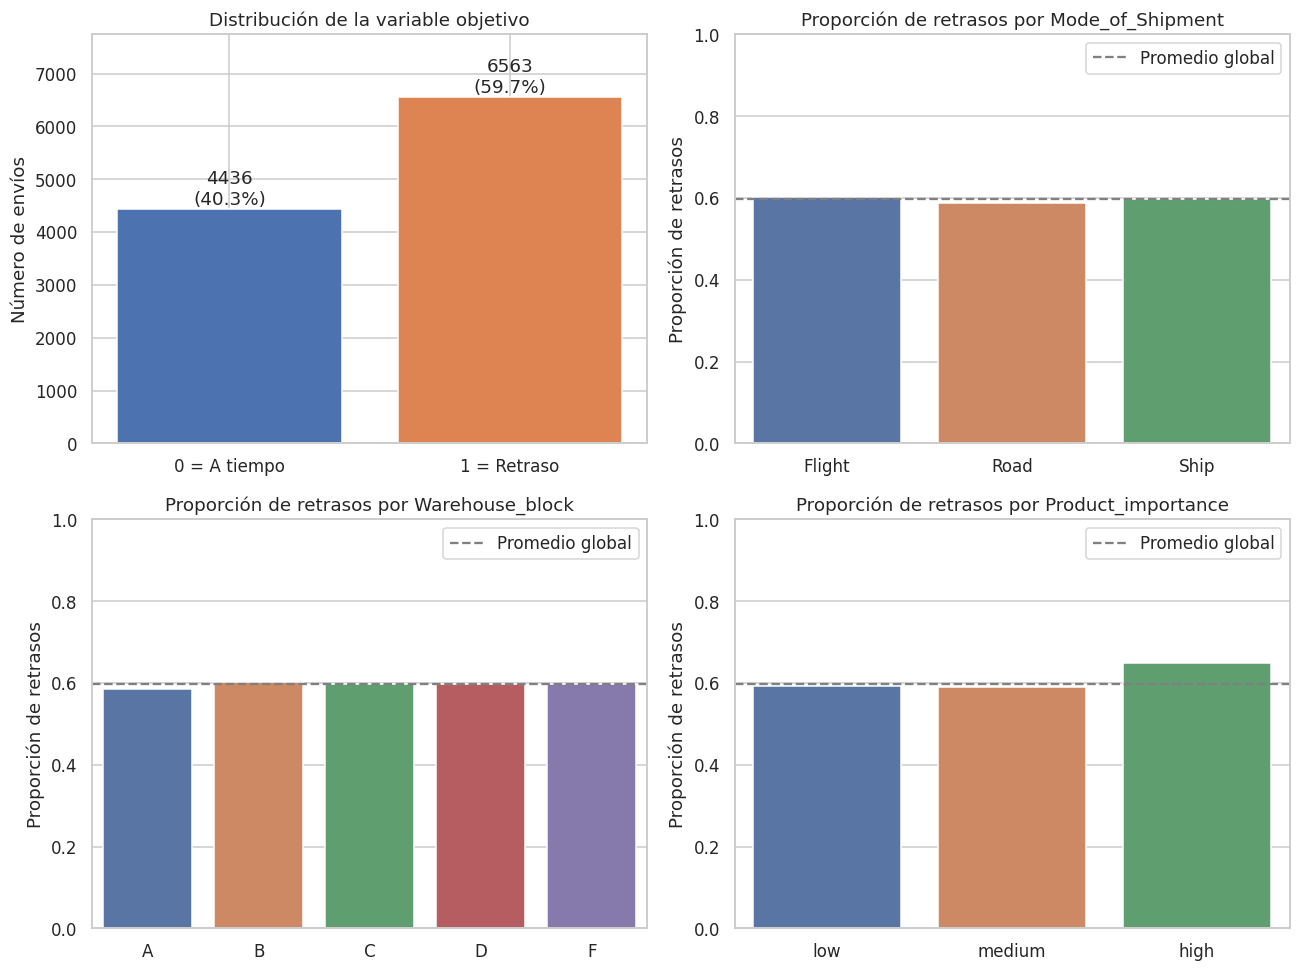

In [5]:
# Distribución del target y tasa de retraso según algunas variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) Distribución de la variable objetivo
conteo = df[TARGET].value_counts().sort_index()
axes[0, 0].bar(["0 = A tiempo", "1 = Retraso"], conteo.values, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(conteo.values):
    axes[0, 0].text(i, v + 80, f"{v}\n({v / len(df):.1%})", ha="center")
axes[0, 0].set_ylim(0, conteo.max() * 1.18)
axes[0, 0].set_title("Distribución de la variable objetivo")
axes[0, 0].set_ylabel("Número de envíos")

# (b-d) Proporción de envíos con retraso por categoría
cols_cat = ["Mode_of_Shipment", "Warehouse_block", "Product_importance"]
for ax, col in zip([axes[0, 1], axes[1, 0], axes[1, 1]], cols_cat):
    tasa = df.groupby(col)[TARGET].mean()
    if col == "Product_importance":
        tasa = tasa.reindex(["low", "medium", "high"])   # orden lógico de la jerarquía
    sns.barplot(x=tasa.index, y=tasa.values, hue=tasa.index, legend=False, ax=ax)
    ax.axhline(df[TARGET].mean(), color="gray", linestyle="--", label="Promedio global")
    ax.set_ylim(0, 1)
    ax.set_title(f"Proporción de retrasos por {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Proporción de retrasos")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

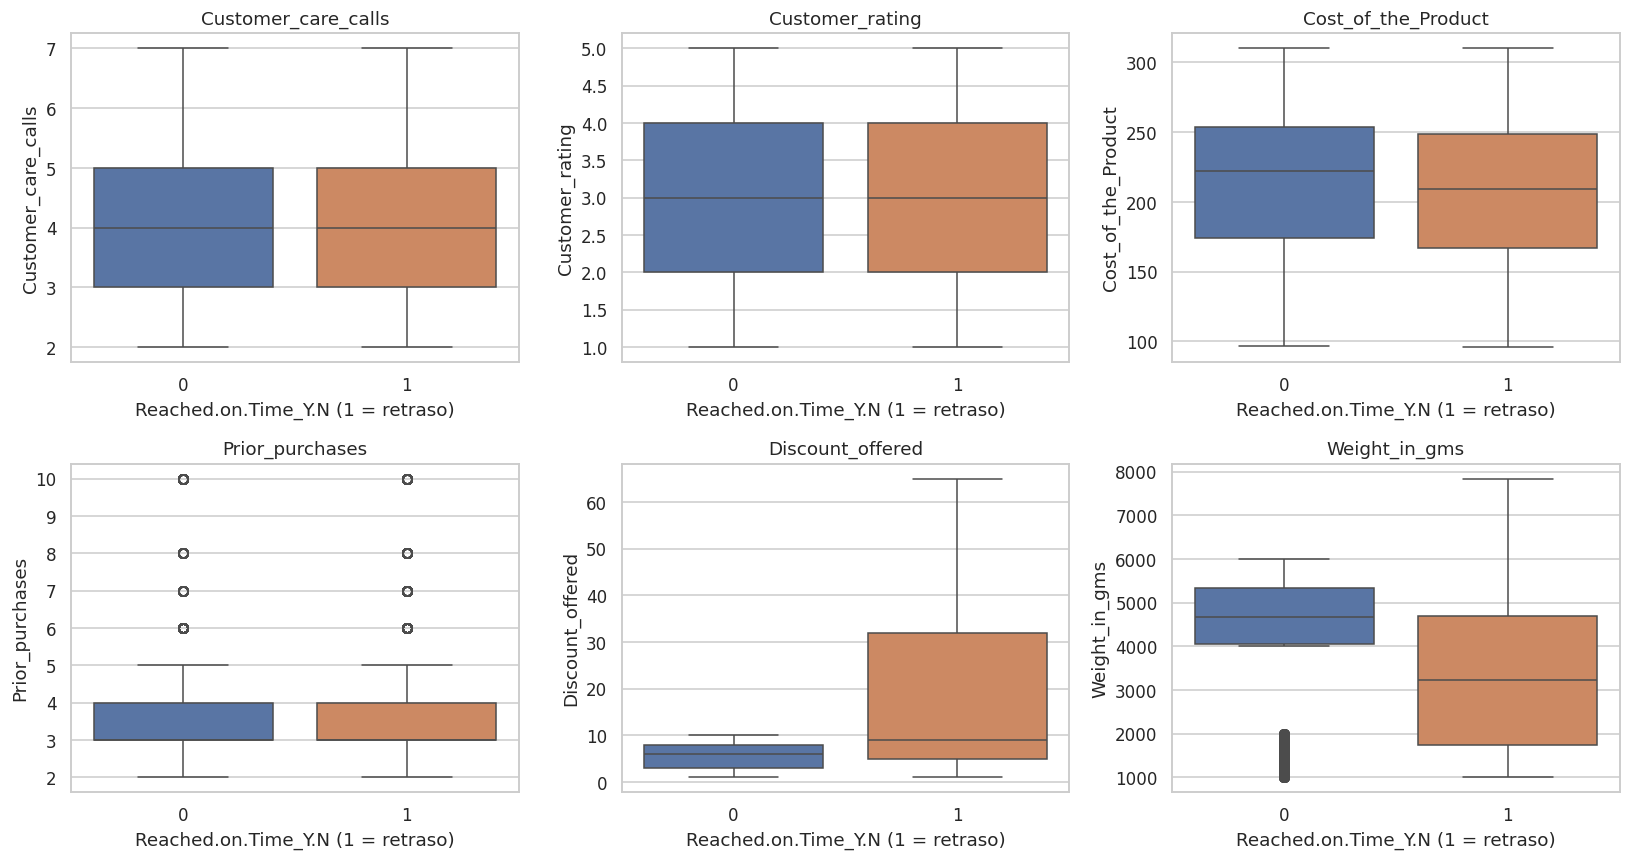

In [6]:
# Distribución de las variables numéricas según el target (0 = a tiempo, 1 = retraso)
cols_num = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
            "Prior_purchases", "Discount_offered", "Weight_in_gms"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), cols_num):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Reached.on.Time_Y.N (1 = retraso)")
plt.tight_layout()
plt.show()

In [7]:
# Hallazgo: relación entre descuento, peso y retraso (solo exploratorio; no se usa como variable del modelo)
desc = df.groupby(df["Discount_offered"] > 10)[TARGET].agg(["count", "mean"])
desc.index = ["Descuento <= 10", "Descuento > 10"]

peso = df.groupby(pd.cut(df["Weight_in_gms"], [0, 2000, 4000, 9000],
                         labels=["<= 2.000 g", "2.000 - 4.000 g", "> 4.000 g"]), observed=True)[TARGET].agg(["count", "mean"])

regla = (df["Discount_offered"] > 10) | ((df["Weight_in_gms"] > 2000) & (df["Weight_in_gms"] <= 4000))
combinada = pd.DataFrame({"count": [regla.sum(), (~regla).sum()],
                          "mean": [df.loc[regla, TARGET].mean(), df.loc[~regla, TARGET].mean()]},
                         index=["Descuento > 10  o  peso 2.000-4.000 g", "Resto de envíos"])

for titulo, tabla in [("Por descuento", desc), ("Por peso", peso), ("Regla combinada", combinada)]:
    tabla.columns = ["n_envios", "proporcion_retrasos"]
    print(titulo)
    display(tabla.round(3))
print(f"Cobertura de la regla: {regla.mean():.1%} de los envíos y {df.loc[regla, TARGET].sum() / df[TARGET].sum():.1%} de todos los retrasos")
print(f"Accuracy de la regla (regla -> retraso, resto -> a tiempo): {((regla.astype(int)) == df[TARGET]).mean():.3f}")

Por descuento


,n_envios,proporcion_retrasos
Descuento <= 10,8352,0.469
Descuento > 10,2647,1.000


Por peso


,n_envios,proporcion_retrasos
Weight_in_gms,,
<= 2.000 g,3245,0.678
2.000 - 4.000 g,1788,0.999
> 4.000 g,5966,0.432


Regla combinada


,n_envios,proporcion_retrasos
Descuento > 10 o peso 2.000-4.000 g,2916,1.000
Resto de envíos,8083,0.451


Cobertura de la regla: 26.5% de los envíos y 44.4% de todos los retrasos
Accuracy de la regla (regla -> retraso, resto -> a tiempo): 0.668


**Hallazgos del análisis exploratorio**

* **Calidad de los datos:** sin valores nulos ni filas duplicadas; no hace falta imputar ni depurar registros.
* **Target moderadamente desbalanceado:** 59,7 % de los envíos tuvo retraso (6.563 de 10.999)
* **Las variables categóricas casi no discriminan:** la tasa de retraso es ~0,59-0,60 en todos los medios de envío y bloques de almacén. Solo los productos de importancia `high` se retrasan algo más (0,650 frente a ~0,59).
* **Calificación y compras previas** tienen distribuciones casi idénticas entre envíos a tiempo y con retraso; el costo del producto es algo menor en los retrasos (mediana 209 frente a 222).



## 2. Preprocesamiento de Datos e Ingeniería de Características

* **`ID`**: es solo un identificador, no tiene poder predictivo.
* **`Product_importance` (ordinal):** `low < medium < high` tiene un orden lógico, así que se codifica con enteros que conservan la jerarquía (`low=1, medium=2, high=3`).
* **`Mode_of_Shipment`, `Warehouse_block` y `Gender` (nominales):** no tienen orden, así que se usa **One-Hot Encoding**.

In [8]:
# Paso 2: Identificación y transformación de variables categóricas
df_model = df.copy()

# 1) Eliminar el identificador
df_model = df_model.drop(columns="ID")

# 2) Encoding ordinal para Product_importance (conserva la jerarquía low < medium < high)
mapa_importancia = {"low": 1, "medium": 2, "high": 3}
df_model["Product_importance"] = df_model["Product_importance"].map(mapa_importancia)
assert df_model["Product_importance"].notna().all(), "Hay categorías de Product_importance sin mapear"

# 3) One-Hot Encoding para las variables nominales
cols_ohe = ["Mode_of_Shipment", "Warehouse_block", "Gender"]
df_model = pd.get_dummies(df_model, columns=cols_ohe, drop_first=True, dtype=int)

print("Columnas después de la codificación:")
print(list(df_model.columns))

Columnas después de la codificación:
['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Gender_M']


In [9]:
# Definición de la matriz de características (X) y el vector objetivo (y)
X = df_model.drop(columns=TARGET)
y = df_model[TARGET]

print("X:", X.shape, "| y:", y.shape)
print("Todas las columnas de X son numéricas:", all(pd.api.types.is_numeric_dtype(t) for t in X.dtypes))
X.head()

X: (10999, 14) | y: (10999,)
Todas las columnas de X son numéricas: True


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Gender_M
0,4,2,177,3,1,44,1233,0,0,0,0,1,0,0
1,4,5,216,2,1,59,3088,0,0,0,0,0,1,1
2,2,2,183,4,1,48,3374,0,0,0,0,0,0,1
3,3,3,176,4,2,10,1177,0,0,1,0,0,0,1
4,2,2,184,3,2,46,2484,0,0,0,1,0,0,0


## 3. División del Dataset

Se separa el 20 % de los datos para prueba, con `random_state` fijo y **estratificando por el target** (`stratify=y`), de modo que train y test conserven la misma proporción de retrasos (~60 %).

In [10]:
# Paso 3: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Proporción de retrasos -> train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

Train: 8799 filas | Test: 2200 filas
Proporción de retrasos -> train: 0.597 | test: 0.597


### Escalado de variables numéricas

Las variables numéricas tienen escalas muy distintas (por ejemplo, `Weight_in_gms` llega a ~7.800 mientras `Customer_rating` va de 1 a 5). Modelos como la Regresión Logística (basada en gradiente y regularización) son sensibles a esto, por lo que aplicamos `StandardScaler` (media 0, desviación 1).


In [11]:
# Columnas numéricas/ordinales a escalar (las dummies 0/1 se dejan como están)
cols_a_escalar = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
                  "Prior_purchases", "Product_importance", "Discount_offered", "Weight_in_gms"]

scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

X_train_sc[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])   # fit SOLO con train
X_test_sc[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])         # solo transform en test

# Verificación: en train, media ~0 y desviación ~1 para las columnas escaladas
comparacion = pd.concat({"Antes (media)": X_train[cols_a_escalar].mean(),
                         "Antes (desv.)": X_train[cols_a_escalar].std(),
                         "Después (media)": X_train_sc[cols_a_escalar].mean(),
                         "Después (desv.)": X_train_sc[cols_a_escalar].std()}, axis=1)
comparacion.round(3)

,Antes (media),Antes (desv.),Después (media),Después (desv.)
Customer_care_calls,4.049,1.139,-0.0,1.0
Customer_rating,2.997,1.411,0.0,1.0
Cost_of_the_Product,210.230,48.051,0.0,1.0
Prior_purchases,3.582,1.533,-0.0,1.0
Product_importance,1.608,0.643,0.0,1.0
Discount_offered,13.367,16.147,0.0,1.0
Weight_in_gms,3631.228,1634.181,0.0,1.0


## 4. Entrenamiento de Modelos

Se entrenan **tres algoritmos distintos**:

1. **Regresión Logística**
2. **Árbol de Decisión**
3. **Random Forest**

* Cada modelo busca sus mejores hiperparámetros con `GridSearchCV` y **validación cruzada estratificada de 5 folds usando solo el conjunto de entrenamiento**.
* Una vez elegida la mejor configuración, se predice sobre el conjunto de **test**, que no se usó para ajustar nada.

In [12]:
# Configuración común: validación cruzada estratificada y contenedores de resultados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos = {}          # mejor estimador de cada modelo (ya entrenado)
predicciones = {}     # clases predichas sobre test
probabilidades = {}   # probabilidad de retraso (clase 1) sobre test
resultados_cv = {}    # accuracy promedio en validación cruzada (solo train)
acc_train = {}        # accuracy sobre train (para detectar sobreajuste)


def registrar_modelo(nombre, busqueda):
    # Guarda el mejor estimador de una búsqueda y sus predicciones sobre test.
    mejor = busqueda.best_estimator_
    modelos[nombre] = mejor
    predicciones[nombre] = mejor.predict(X_test_sc)
    probabilidades[nombre] = mejor.predict_proba(X_test_sc)[:, 1]
    resultados_cv[nombre] = busqueda.best_score_
    acc_train[nombre] = mejor.score(X_train_sc, y_train)
    print(f"{nombre}")
    print(f"  Mejores hiperparámetros: {busqueda.best_params_}")
    print(f"  Accuracy en validación cruzada (train): {busqueda.best_score_:.4f}")

In [13]:
# Modelo 1: Regresión Logística (se ajusta la fuerza de regularización C)
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid={"C": [0.001, 0.01, 0.1, 1, 10]},
    cv=cv, scoring="accuracy", n_jobs=-1
)
gs_lr.fit(X_train_sc, y_train)
registrar_modelo("Regresión Logística", gs_lr)

Regresión Logística
  Mejores hiperparámetros: {'C': 0.01}
  Accuracy en validación cruzada (train): 0.6400


In [14]:
# Modelo 2: Árbol de Decisión (se limita la complejidad para evitar sobreajuste)
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid={"max_depth": [3, 4, 5, 6, 8, 10, None],
                "min_samples_leaf": [1, 10, 30, 50, 100]},
    cv=cv, scoring="accuracy", n_jobs=-1
)
gs_dt.fit(X_train_sc, y_train)
registrar_modelo("Árbol de Decisión", gs_dt)

Árbol de Decisión
  Mejores hiperparámetros: {'max_depth': 5, 'min_samples_leaf': 50}
  Accuracy en validación cruzada (train): 0.6838


In [15]:
# Modelo 3: Random Forest (200 árboles; se ajusta profundidad y tamaño mínimo de hoja)
gs_rf = GridSearchCV(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    param_grid={"max_depth": [4, 6, 8, 10],
                "min_samples_leaf": [1, 5, 20]},
    cv=cv, scoring="accuracy", n_jobs=-1
)
gs_rf.fit(X_train_sc, y_train)
registrar_modelo("Random Forest", gs_rf)

Random Forest
  Mejores hiperparámetros: {'max_depth': 8, 'min_samples_leaf': 5}
  Accuracy en validación cruzada (train): 0.6801


## 5. Evaluación y Comparación de Resultados

Todas las métricas se calculan sobre el conjunto de **test**. Como el objetivo del negocio es anticipar los retrasos, las métricas de precisión, recall y F1 se reportan para la **clase positiva (1 = retraso)**.

In [16]:
# Paso 5: Cálculo de métricas para cada modelo
filas = []
for nombre, y_pred in predicciones.items():
    filas.append({
        "Modelo": nombre,
        "Accuracy (test)": accuracy_score(y_test, y_pred),
        "Precision (retraso)": precision_score(y_test, y_pred),
        "Recall (retraso)": recall_score(y_test, y_pred),
        "F1 (retraso)": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, probabilidades[nombre]),
        "Accuracy CV (train)": resultados_cv[nombre],
        "Accuracy (train)": acc_train[nombre],
    })

df_metricas = pd.DataFrame(filas).set_index("Modelo").round(4)
display(df_metricas)

print("\nMejor modelo según cada métrica:")
print(df_metricas.idxmax().to_string())

,Accuracy (test),Precision (retraso),Recall (retraso),F1 (retraso),ROC-AUC,Accuracy CV (train),Accuracy (train)
Modelo,,,,,,,
Regresión Logística,0.6427,0.7035,0.6938,0.6986,0.7238,0.6400,0.6409
Árbol de Decisión,0.6782,0.9563,0.4829,0.6417,0.7379,0.6838,0.6912
Random Forest,0.6809,0.9249,0.5065,0.6545,0.7441,0.6801,0.7227



Mejor modelo según cada métrica:
Accuracy (test)              Random Forest
Precision (retraso)      Árbol de Decisión
Recall (retraso)       Regresión Logística
F1 (retraso)           Regresión Logística
ROC-AUC                      Random Forest
Accuracy CV (train)      Árbol de Decisión
Accuracy (train)             Random Forest


In [17]:
# Reporte de clasificación detallado por modelo
for nombre, y_pred in predicciones.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=["A tiempo (0)", "Retraso (1)"], digits=3))

Regresión Logística
              precision    recall  f1-score   support

A tiempo (0)      0.556     0.567     0.561       887
 Retraso (1)      0.703     0.694     0.699      1313

    accuracy                          0.643      2200
   macro avg      0.630     0.630     0.630      2200
weighted avg      0.644     0.643     0.643      2200

Árbol de Decisión
              precision    recall  f1-score   support

A tiempo (0)      0.558     0.967     0.708       887
 Retraso (1)      0.956     0.483     0.642      1313

    accuracy                          0.678      2200
   macro avg      0.757     0.725     0.675      2200
weighted avg      0.796     0.678     0.668      2200

Random Forest
              precision    recall  f1-score   support

A tiempo (0)      0.562     0.939     0.704       887
 Retraso (1)      0.925     0.506     0.655      1313

    accuracy                          0.681      2200
   macro avg      0.744     0.723     0.679      2200
weighted avg      0.77

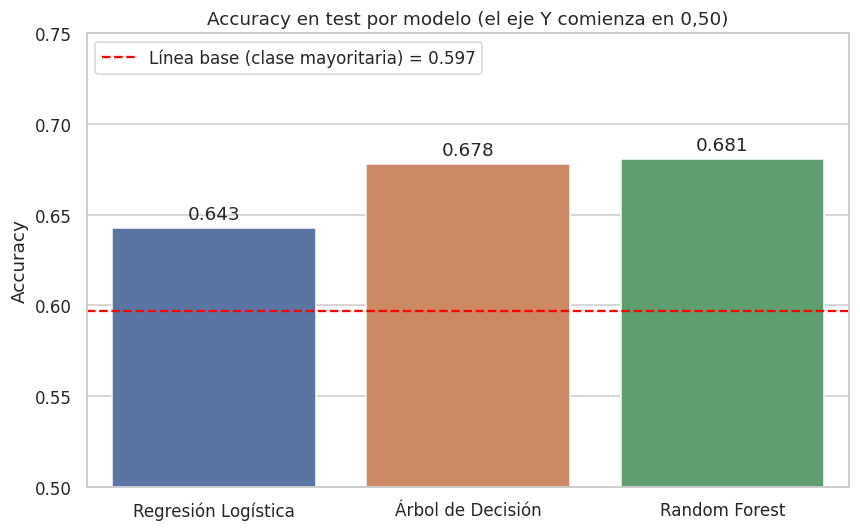

In [18]:
# Paso 6: Gráfica comparativa de Accuracy (con la línea base de la clase mayoritaria)
baseline = max(y_test.mean(), 1 - y_test.mean())

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas["Accuracy (test)"],
                 hue=df_metricas.index, legend=False)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.3f", padding=3)
plt.axhline(baseline, color="red", linestyle="--", label=f"Línea base (clase mayoritaria) = {baseline:.3f}")
plt.ylim(0.5, 0.75)
plt.title("Accuracy en test por modelo (el eje Y comienza en 0,50)")
plt.xlabel("")
plt.ylabel("Accuracy")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

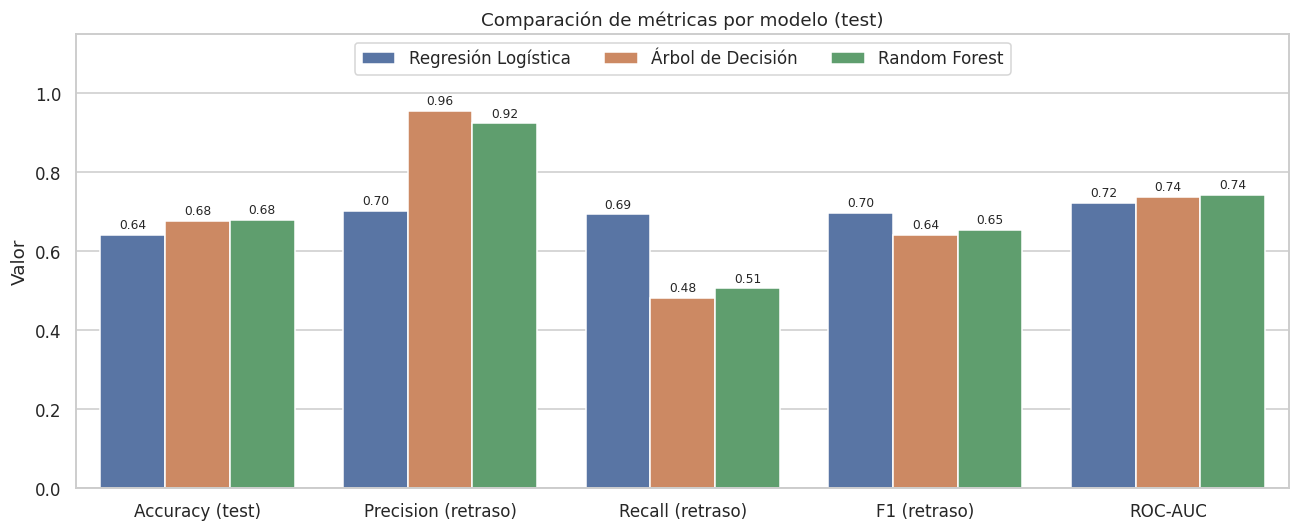

In [19]:
# Comparación de todas las métricas (clase positiva = retraso)
metricas_plot = df_metricas[["Accuracy (test)", "Precision (retraso)", "Recall (retraso)",
                             "F1 (retraso)", "ROC-AUC"]].reset_index()
metricas_largo = metricas_plot.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=metricas_largo, x="Métrica", y="Valor", hue="Modelo")
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.2f", fontsize=8, padding=2)
plt.ylim(0, 1.15)
plt.title("Comparación de métricas por modelo (test)")
plt.xlabel("")
plt.legend(loc="upper center", ncol=3)
plt.tight_layout()
plt.show()

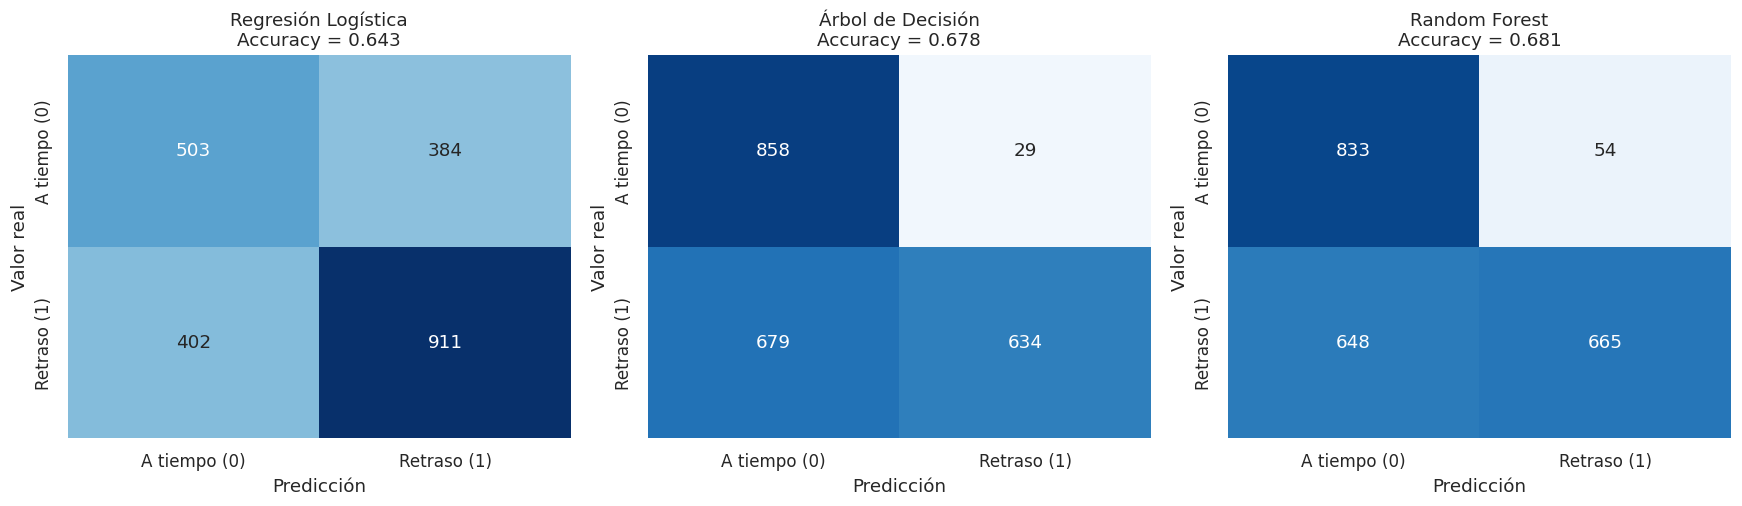

In [20]:
# Paso 7: Matrices de confusión
etiquetas = ["A tiempo (0)", "Retraso (1)"]

vmax = max(confusion_matrix(y_test, p).max() for p in predicciones.values())   # misma escala de color en los tres

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (nombre, y_pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, vmin=0, vmax=vmax,
                xticklabels=etiquetas, yticklabels=etiquetas, ax=ax)
    ax.set_title(f"{nombre}\nAccuracy = {accuracy_score(y_test, y_pred):.3f}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()

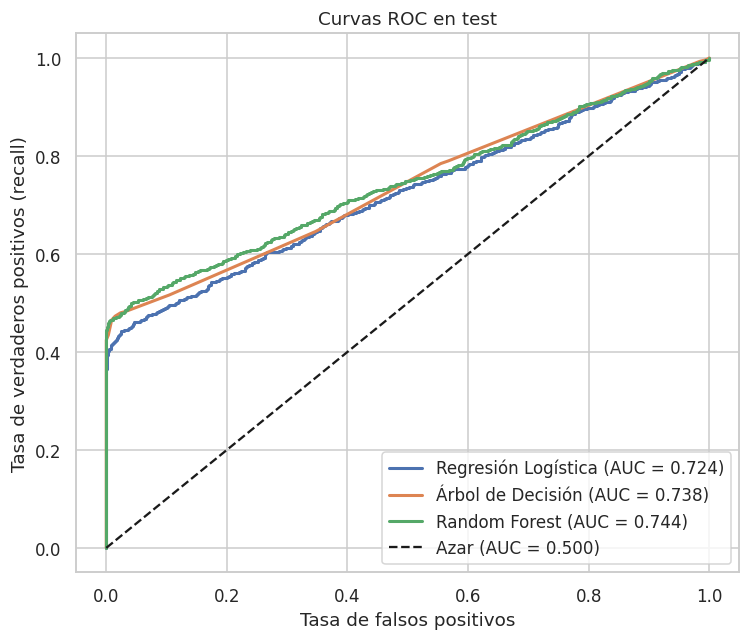

In [21]:
# Curvas ROC: capacidad de discriminación independiente del umbral
plt.figure(figsize=(7, 6))
for nombre, proba in probabilidades.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{nombre} (AUC = {roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Azar (AUC = 0.500)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curvas ROC en test")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Modelo con mayor accuracy en test: Random Forest
Discount_offered + Weight_in_gms concentran 79.9% de la importancia total


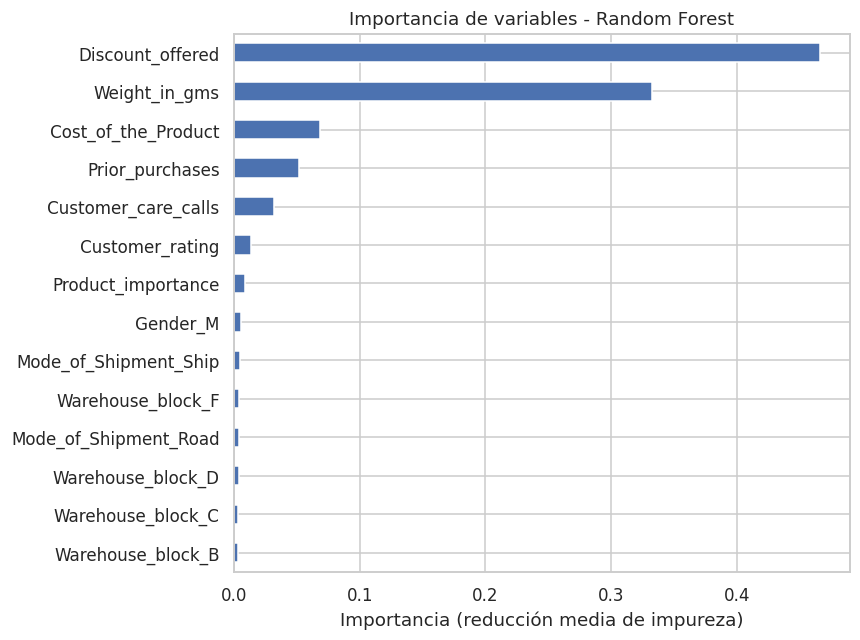

In [22]:
# ¿Qué variables usa el mejor modelo? Importancia de variables
mejor_nombre = df_metricas["Accuracy (test)"].idxmax()
mejor_modelo = modelos[mejor_nombre]
print("Modelo con mayor accuracy en test:", mejor_nombre)

if hasattr(mejor_modelo, "feature_importances_"):
    importancias = pd.Series(mejor_modelo.feature_importances_, index=X_train_sc.columns).sort_values()
    print(f"Discount_offered + Weight_in_gms concentran {importancias[['Discount_offered', 'Weight_in_gms']].sum():.1%} de la importancia total")
    plt.figure(figsize=(8, 6))
    importancias.plot.barh(color="#4C72B0")
    plt.title(f"Importancia de variables - {mejor_nombre}")
    plt.xlabel("Importancia (reducción media de impureza)")
    plt.tight_layout()
    plt.show()

## 6. Conclusiones

### Modelo Seleccionado: Random Forest

| Modelo | Accuracy (test) | ROC-AUC | Precision (retraso) | Recall (retraso) | F1 (retraso) |
|---|:---:|:---:|:---:|:---:|:---:|
| Regresión Logística | 0,643 | 0,724 | 0,704 | **0,694** | **0,699** |
| Árbol de Decisión | 0,678 | 0,738 | **0,956** | 0,483 | 0,642 |
| **Random Forest** | **0,681** | **0,744** | 0,925 | 0,507 | 0,655 |

* **¿Por qué Random Forest?:** Ofrece el mejor rendimiento general (Accuracy 0,681 y ROC-AUC 0,744) y mayor estabilidad al promediar 200 árboles, evaluando bien las relaciones no lineales.
* **Perfil de error:** Genera pocas falsas alarmas (Precision 92,5 %), pero omite la mitad de los retrasos (Recall 50,7 %). Si el negocio requiere capturar más retrasos, se debe ajustar el umbral de decisión.
* **Variables clave:** `Discount_offered` y `Weight_in_gms` concentran el 79,9 % del poder predictivo.
* **Próximos pasos:** Ajustar umbral por costo de negocio, incluir variables de logistíca/rutas y probar modelos de Gradient Boosting.